# Continuous Rootzone Only t0 To t1 V2

In [102]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
import optuna
from sklearn.model_selection import TimeSeriesSplit

# ==========================================
# 1. Data Loading & Helper Functions
# ==========================================
df = pd.read_csv('master.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
master_df = df.copy().sort_index()
print(f'Loaded: {len(df)} rows')

ACID_FERTS = ['Phosphoric acid[mg]-H3PO4']
SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
              'Kortin [mg]', 'Ammonium Nitrate [mg] -NH4NO3', 'Gypsum - CaSO4*2H2O [mg]']

def _to_num(s, d=0.0): return pd.to_numeric(s, errors='coerce').fillna(d)

def _sum_avail(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return float(fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sum()) if u else 0.0

def _sum_avail_series(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if u else pd.Series(0.0, index=fr.index)

def _get_fert_any(fr):
    if 'fertilization_flag' in fr.columns: return _to_num(fr['fertilization_flag'])
    a = 'fertilization_type_a_flag' in fr.columns
    b = 'fertilization_type_b_flag' in fr.columns
    if a or b:
        fa = _to_num(fr['fertilization_type_a_flag']) if a else pd.Series(0., index=fr.index)
        fb = _to_num(fr['fertilization_type_b_flag']) if b else pd.Series(0., index=fr.index)
        return ((fa > 0) | (fb > 0)).astype(float)
    return pd.Series(0., index=fr.index)

Loaded: 16682 rows


In [103]:
# ==========================================
# 2. Feature Extraction (Cleaned)
# ==========================================
def get_features_for_row(master_df, anchor_idx, current_idx):
    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    ph0 = float(master_df.loc[t0, 'ph'])
    ec0 = float(master_df.loc[t0, 'ec_ms'])
    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 0.16)
    seg = master_df.loc[t0:t1]

    # Absolute sums for unweighted drivers (EC model prefers these)
    fa = _sum_avail(seg, ACID_FERTS)
    fs = _sum_avail(seg, SALT_FERTS)
    tf = fa + fs
    irr_sum = float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns else 0.

    # Time-Weighted Event Aggregation (Exponential Decay)
    fa_s = _sum_avail_series(seg, ACID_FERTS)
    fs_s = _sum_avail_series(seg, SALT_FERTS)
    tf_s = fa_s + fs_s
    irr_s = _to_num(seg['irrigation_ml_current']) if 'irrigation_ml_current' in seg.columns else pd.Series(0.0, index=seg.index)
    
    time_to_t1_hours = (t1 - seg.index).total_seconds() / 3600.0
    decay_lambda = 0.34
    weights = np.exp(-decay_lambda * time_to_t1_hours)
    
    weighted_irr = float((irr_s * weights).sum())
    weighted_fert_acid = float((fa_s * weights).sum())
    weighted_fert_salt = float((fs_s * weights).sum())
    weighted_total_fert = float((tf_s * weights).sum())
    fert_concentration = tf / (irr_sum + 1e-6)
    

    # Agronomic drivers
    fc = float(tf / (irr_sum + 1.0))
    log_ecd = float(np.log(fc + 0.01) - np.log(ec0 + 0.01))
    phd = float(tf / (ph0 + 1e-3))
    
    et0s = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.
    et0h = float(et0s / safe_gap_h)
    
    # Leaching fraction: Balanced pad (+0.1) prevents EC noise but keeps pH signal
    ET0_sum = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.0
    irr_total = float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns else 0.0
    leaching_fraction = float(irr_total / (ET0_sum + 1e-3))

    # Climate dynamics
    if 'internal_air_temp_c' in seg.columns and 'internal_rh_%' in seg.columns:
        ts = _to_num(seg['internal_air_temp_c']); rhs = _to_num(seg['internal_rh_%'])
        ess = 0.6108 * np.exp((17.27 * ts) / (ts + 237.3))
        vpds = ess * (1. - rhs / 100.)
        vpd_m = float(vpds.mean()) if len(vpds) > 0 else 0.
    else: vpd_m = 0.
        
    st = float(_to_num(seg['soil_temp_pred']).mean()) if 'soil_temp_pred' in seg.columns else 0.
    can = float(_to_num(seg['canopy_cover']).mean()) if 'canopy_cover' in seg.columns else 0.

    temp_s = _to_num(seg['internal_air_temp_c']) if 'internal_air_temp_c' in seg.columns else pd.Series(dtype=float)
    if len(temp_s) > 1:
        temp_trend = float(temp_s.iloc[-1] - temp_s.iloc[0])
        temp_range = float(temp_s.max() - temp_s.min())
    else:
        temp_trend, temp_range = 0.0, 0.0

    rad_s = _to_num(seg['internal_radiation']) if 'internal_radiation' in seg.columns else pd.Series(dtype=float)
    rad_max = float(rad_s.max()) if len(rad_s) > 0 else 0.0
    daylight_proportion = float((rad_s > 10).sum() / 6.0 / safe_gap_h) if len(rad_s) > 0 else 0.0

    # Hours since events
    if 'irrigation_ml_current' in seg.columns:
        ie = _to_num(seg['irrigation_ml_current']); ii = ie[ie > 0].index
        hsi = float((t1 - ii.max()).total_seconds() / 3600.) if len(ii) > 0 else gap_h
    else: hsi = gap_h
    
    fser = _get_fert_any(seg); fi2 = fser[fser > 0].index
    hsf = float((t1 - fi2.max()).total_seconds() / 3600.) if len(fi2) > 0 else gap_h

    # Time of day (Diurnal cycles)
    hour_a = t0.hour + t0.minute / 60.0
    hour_b = t1.hour + t1.minute / 60.0



    return {
        'ph0': ph0, 'ec0': ec0, 'gap_hours': gap_h,
        'weighted_irr': weighted_irr, 'weighted_total_fert': weighted_total_fert,
        'weighted_fert_acid': weighted_fert_acid, 'weighted_fert_salt': weighted_fert_salt,
        'fert_conc': fc, 'log_ec_drive': log_ecd, 'ph_drive': phd, 
        'leaching_fraction': leaching_fraction, 'transpiration_pull': vpd_m * can,
        'daylight_proportion': daylight_proportion, 'rad_max': rad_max, 
        'vpd_mean': vpd_m, 'soil_temp_mean': st, 'ET0_per_hour': et0h, 'canopy': can,
        'hrs_since_irr': hsi, 'hrs_since_fert': hsf,
        'temp_trend': temp_trend, 'temp_range': temp_range,
        'hour_sin_a': float(np.sin(2 * np.pi * hour_a / 24)),
        'hour_cos_a': float(np.cos(2 * np.pi * hour_a / 24)),
        'hour_sin_b': float(np.sin(2 * np.pi * hour_b / 24)),
        'hour_cos_b': float(np.cos(2 * np.pi * hour_b / 24)),
        'fert_concentration': fert_concentration,
    }

In [104]:
# ==========================================
# 3. Exact Feature Lists (Optimized)
# ==========================================
feature_cols_ph = [
    'ph0', 'ec0', 
    'weighted_irr', 'weighted_total_fert', 
    'fert_conc', 'ph_drive', 'leaching_fraction',             
    'hrs_since_irr', 'hrs_since_fert',
    'vpd_mean', 'soil_temp_mean', 'ET0_per_hour',
    'gap_hours', 'canopy', 'transpiration_pull',
    'temp_trend', 'temp_range', 'rad_max',
    'hour_sin_a', 'hour_cos_a', 'hour_sin_b', 'hour_cos_b', 'fert_concentration'
]

feature_cols_ec = [
    'ec0', 'ph0',
    'weighted_irr', 'weighted_fert_salt',
    'log_ec_drive', 'leaching_fraction',  
    'hrs_since_irr', 'hrs_since_fert', 'ET0_per_hour',
    'temp_trend', 'fert_concentration', 
]

best_ph_params = {
    'n_estimators': 604,
    'learning_rate': 0.038,
    'max_depth': 3,
    'min_child_weight': 5,
    'subsample': 0.65,
    'colsample_bytree': 0.74,
    'reg_alpha': 1.33,
    'reg_lambda': 1.13,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

best_ec_params = {
    'n_estimators': 100,
    'learning_rate': 0.05,
    'max_depth': 2,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.3,
    'reg_lambda': 1.5,
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'reg:pseudohubererror',
    'huber_slope': 0.1,
}

In [105]:
# ==========================================
# 4. Walk-Forward Validation & Training
# ==========================================
def fit_models(tdf, ph_params=None, ec_params=None):
    y_ph = tdf['ph_true'] - tdf['ph0']
    y_ec = tdf['ec_true'] - tdf['ec0']

    pm = xgb.XGBRegressor(**(ph_params or {}))
    em = xgb.XGBRegressor(**(ec_params or {}))

    pm.fit(tdf[feature_cols_ph], y_ph, verbose=False)
    em.fit(tdf[feature_cols_ec], y_ec, verbose=False)
    return pm, em


def run_walkforward(master_df, sensor_idx, warmup, ph_params=None, ec_params=None, retrain_every_sample=True):
    train_rows = []
    for j in range(1, warmup + 1):
        f = get_features_for_row(master_df, sensor_idx[j-1], sensor_idx[j])
        f['ph_true'] = float(master_df.loc[sensor_idx[j], 'ph'])
        f['ec_true'] = float(master_df.loc[sensor_idx[j], 'ec_ms'])
        f['timestamp'] = sensor_idx[j]
        train_rows.append(f)
    train_df = pd.DataFrame(train_rows).set_index('timestamp').sort_index()

    ph_model, ec_model = fit_models(train_df, ph_params, ec_params)

    anchor_idx = sensor_idx[warmup]
    results = []
    retrain_count = 0

    for cur in master_df.loc[anchor_idx:].index:
        feats = get_features_for_row(master_df, anchor_idx, cur)

        dph = float(ph_model.predict(pd.DataFrame([feats])[feature_cols_ph])[0])
        dec = float(ec_model.predict(pd.DataFrame([feats])[feature_cols_ec])[0])

        ph_pred = feats['ph0'] + dph
        ec_pred = max(0.0, feats['ec0'] + dec)

        row = {
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            'ph0': feats['ph0'], 'ec0': feats['ec0'],
            'ph_pred': ph_pred, 'ec_pred': ec_pred,
            'has_actual': False,
            'ph_true': np.nan, 'ec_true': np.nan,
            'ph_naive': np.nan, 'ec_naive': np.nan,
            'ph_abs_error': np.nan, 'ec_abs_error': np.nan,
            'ph_abs_error_naive': np.nan, 'ec_abs_error_naive': np.nan
        }

        has = pd.notna(master_df.loc[cur, 'ph']) and pd.notna(master_df.loc[cur, 'ec_ms'])
        if has:
            ph_true = float(master_df.loc[cur, 'ph'])
            ec_true = float(master_df.loc[cur, 'ec_ms'])

            row.update({
                'has_actual': True,
                'ph_true': ph_true, 'ec_true': ec_true,
                'ph_naive': feats['ph0'], 'ec_naive': feats['ec0'],
                'ph_abs_error': abs(ph_pred - ph_true),
                'ec_abs_error': abs(ec_pred - ec_true),
                'ph_abs_error_naive': abs(feats['ph0'] - ph_true),
                'ec_abs_error_naive': abs(feats['ec0'] - ec_true),
            })

            if retrain_every_sample and cur != anchor_idx:
                nr = {**feats, 'ph_true': ph_true, 'ec_true': ec_true, 'timestamp': cur}
                train_df = pd.concat([train_df, pd.DataFrame([nr]).set_index('timestamp')]).sort_index()
                ph_model, ec_model = fit_models(train_df, ph_params, ec_params)
                retrain_count += 1

            anchor_idx = cur

        results.append(row)

    res_df = pd.DataFrame(results).set_index('timestamp')
    ev = res_df[res_df['has_actual']].copy()

    def _rmse(y, yhat):
        return float(np.sqrt(mean_squared_error(y, yhat)))

    metrics = {
        'warmup': warmup,
        'n_test': int(len(ev)),
        'retrains': int(retrain_count),
        'ph_mae': float(mean_absolute_error(ev['ph_true'], ev['ph_pred'])) if len(ev) else np.nan,
        'ph_rmse': _rmse(ev['ph_true'], ev['ph_pred']) if len(ev) else np.nan,
        'ph_mae_naive': float(mean_absolute_error(ev['ph_true'], ev['ph_naive'])) if len(ev) else np.nan,
        'ec_mae': float(mean_absolute_error(ev['ec_true'], ev['ec_pred'])) if len(ev) else np.nan,
        'ec_rmse': _rmse(ev['ec_true'], ev['ec_pred']) if len(ev) else np.nan,
        'ec_mae_naive': float(mean_absolute_error(ev['ec_true'], ev['ec_naive'])) if len(ev) else np.nan,
        'ph_r2': float(r2_score(ev['ph_true'], ev['ph_pred'])) if len(ev) >= 2 else np.nan,
        'ec_r2': float(r2_score(ev['ec_true'], ev['ec_pred'])) if len(ev) >= 2 else np.nan,
    }

    return metrics, ev, res_df, ph_model, ec_model

In [106]:
# ==========================================
# 5. Evaluation & Output
# ==========================================
sensor_idx = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])

warmups = [50]
all_metrics = []
runs = {}

for w in warmups:
    m, ev_w, res_w, pm_w, em_w = run_walkforward(
        master_df, sensor_idx, warmup=w,
        ph_params=best_ph_params,
        ec_params=best_ec_params
    )
    all_metrics.append(m)
    runs[w] = {'ev': ev_w, 'res': res_w, 'ph_model': pm_w, 'ec_model': em_w}

summary = pd.DataFrame(all_metrics).sort_values('warmup')
summary['ph_gain_mae'] = summary['ph_mae_naive'] - summary['ph_mae']
summary['ec_gain_mae'] = summary['ec_mae_naive'] - summary['ec_mae']

print(summary[['warmup','n_test','retrains',
               'ph_mae','ph_mae_naive','ph_gain_mae','ph_r2',
               'ec_mae','ec_mae_naive','ec_gain_mae','ec_r2']])

   warmup  n_test  retrains    ph_mae  ph_mae_naive  ph_gain_mae     ph_r2  \
0      50      59        58  0.449994      0.906271     0.456277  0.848924   

   ec_mae  ec_mae_naive  ec_gain_mae     ec_r2  
0  0.1875      0.191769     0.004269  0.820444  


In [107]:
def gap_bin_report(ev):
    ev = ev.copy()
    ev['gap_bin'] = pd.cut(ev['gap_hours'], [-np.inf, 12, 24, np.inf], labels=['0-12h', '12-24h', '24h+'])
    out = []
    for gb, g in ev.groupby('gap_bin', observed=False):
        if len(g) == 0: 
            continue
        out.append({
            'gap_bin': str(gb),
            'n': len(g),
            'ph_mae': g['ph_abs_error'].mean(),
            'ph_naive': g['ph_abs_error_naive'].mean(),
            'ec_mae': g['ec_abs_error'].mean(),
            'ec_naive': g['ec_abs_error_naive'].mean(),
        })
    return pd.DataFrame(out)

for w in warmups:
    print(f"\n=== Warmup {w} gap-bin ===")
    display(gap_bin_report(runs[w]['ev']))


=== Warmup 50 gap-bin ===


,gap_bin,n,ph_mae,ph_naive,ec_mae,ec_naive
0,0-12h,45,0.454338,0.714667,0.214331,0.213804
1,12-24h,11,0.420547,1.641818,0.114690,0.119655
2,24h+,3,0.492809,1.083333,0.052005,0.125667


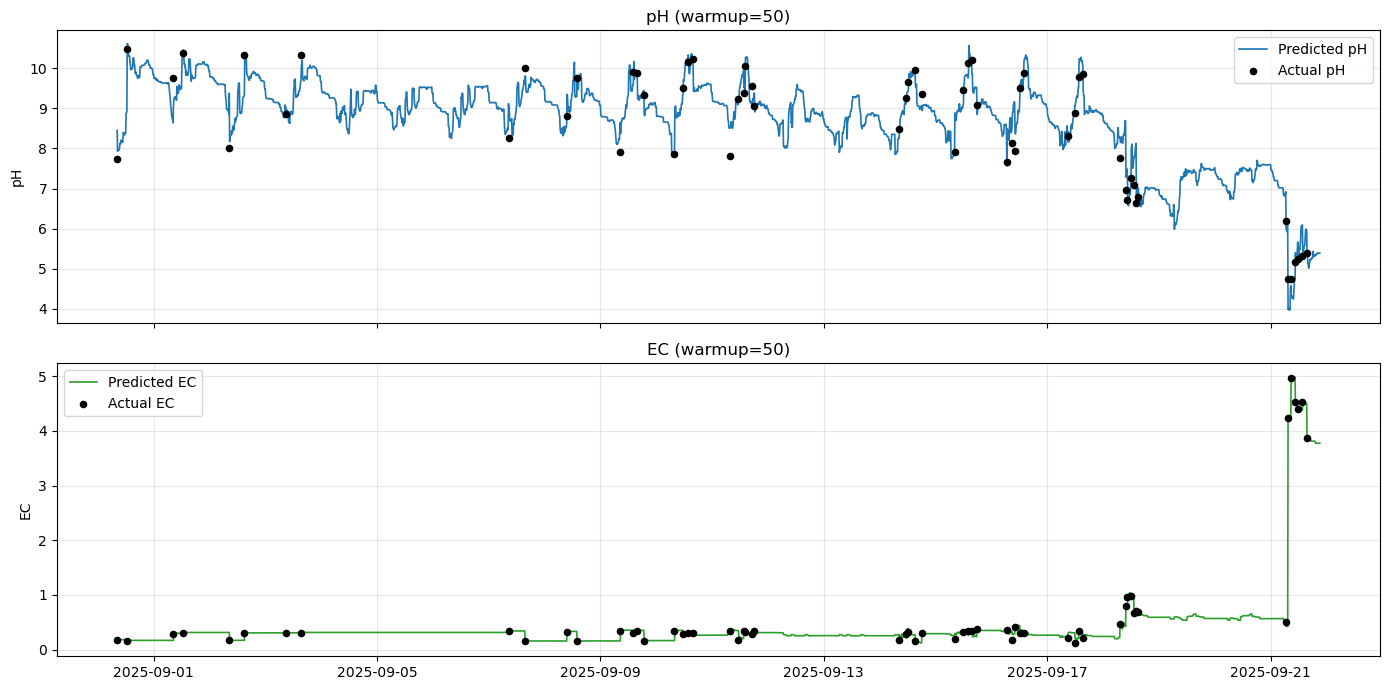

In [108]:
for w in warmups:
    ev = runs[w]['ev']
    res_df = runs[w]['res']

    fig,ax=plt.subplots(2,1,figsize=(14,7),sharex=True)

    ax[0].plot(res_df.index,res_df['ph_pred'],color='tab:blue',lw=1.2,label='Predicted pH')
    ax[0].scatter(ev.index,ev['ph_true'],color='black',s=20,zorder=5,label='Actual pH')
    ax[0].set_ylabel('pH')
    ax[0].set_title(f'pH (warmup={w})')
    ax[0].legend()
    ax[0].grid(True,alpha=0.3)

    ax[1].plot(res_df.index,res_df['ec_pred'],color='tab:green',lw=1.2,label='Predicted EC')
    ax[1].scatter(ev.index,ev['ec_true'],color='black',s=20,zorder=5,label='Actual EC')
    ax[1].set_ylabel('EC')
    ax[1].set_title(f'EC (warmup={w})')
    ax[1].legend()
    ax[1].grid(True,alpha=0.3)

    plt.tight_layout()
    plt.show()

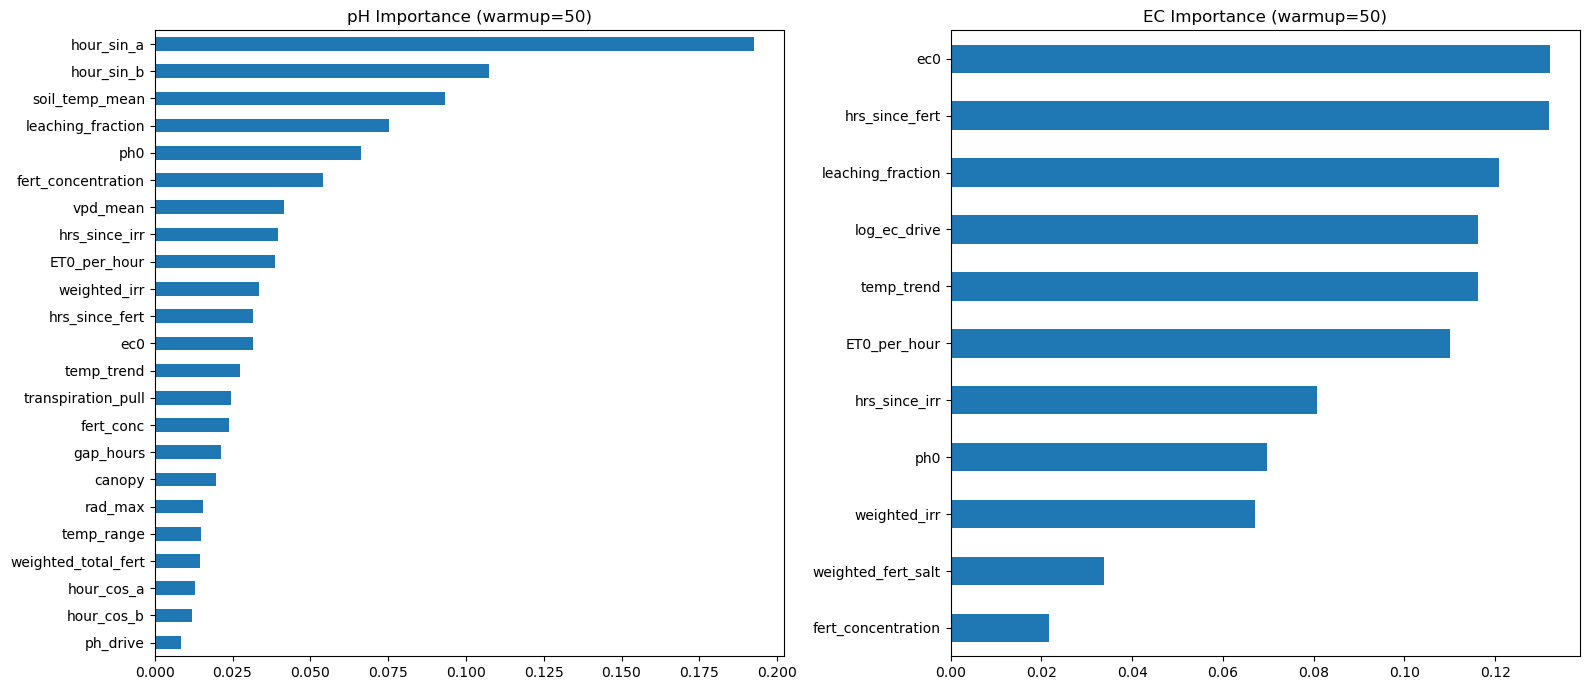

In [109]:
for w in warmups:
    ph_model = runs[w]['ph_model']
    ec_model = runs[w]['ec_model']

    fig,axes=plt.subplots(1,2,figsize=(16,7))

    pd.Series(ph_model.feature_importances_,index=feature_cols_ph)\
        .sort_values()\
        .plot(kind='barh',ax=axes[0],title=f'pH Importance (warmup={w})')

    pd.Series(ec_model.feature_importances_,index=feature_cols_ec)\
        .sort_values()\
        .plot(kind='barh',ax=axes[1],title=f'EC Importance (warmup={w})')

    plt.tight_layout()
    plt.show()

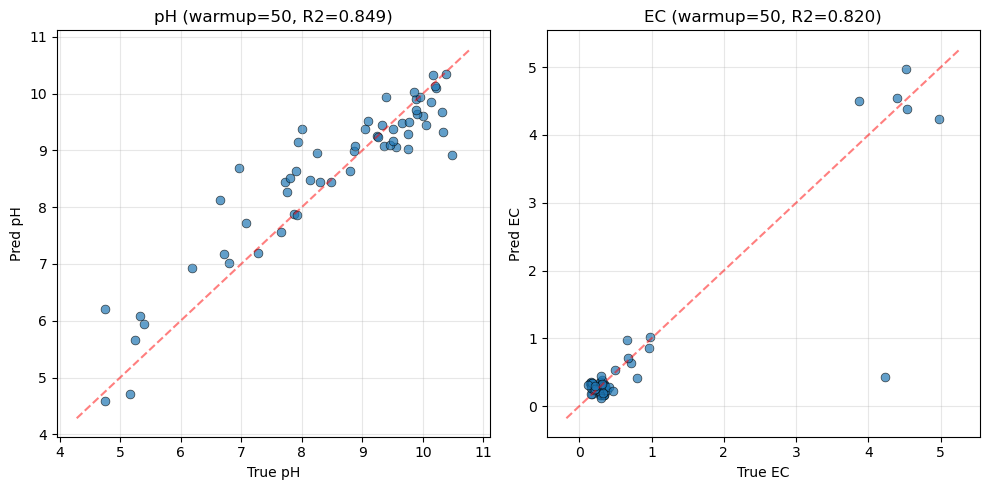

In [110]:
for w in warmups:
    ev = runs[w]['ev']

    fig,axes=plt.subplots(1,2,figsize=(10,5))

    for i,(n,tc,pc) in enumerate([('pH','ph_true','ph_pred'),('EC','ec_true','ec_pred')]):
        ax=axes[i]
        t=ev[tc].values
        p=ev[pc].values

        ax.scatter(t,p,alpha=0.7,s=40,edgecolors='k',lw=0.5)

        lims=[min(t.min(),p.min())-0.3,max(t.max(),p.max())+0.3]
        ax.plot(lims,lims,'r--',alpha=0.5)

        ax.set_xlabel(f'True {n}')
        ax.set_ylabel(f'Pred {n}')
        ax.set_title(f'{n} (warmup={w}, R2={r2_score(t,p):.3f})')
        ax.grid(True,alpha=0.3)

    plt.tight_layout()
    plt.show()

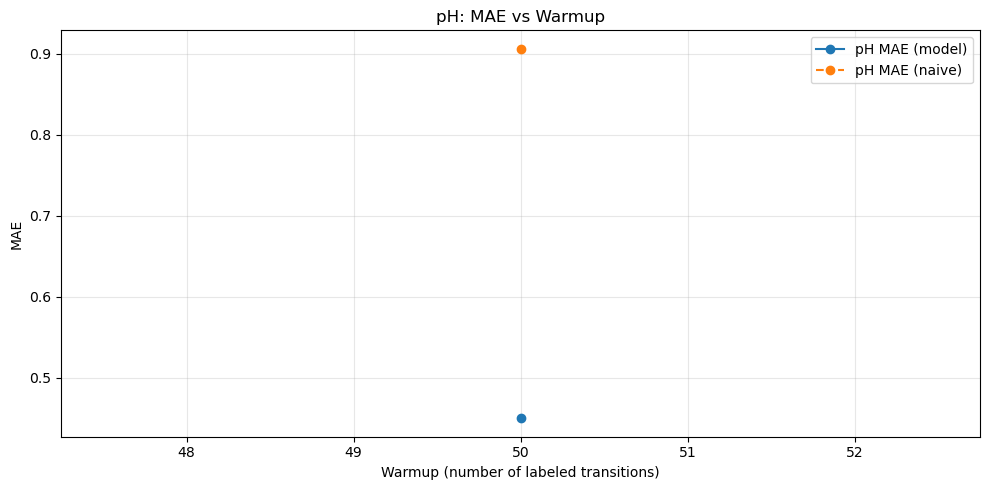

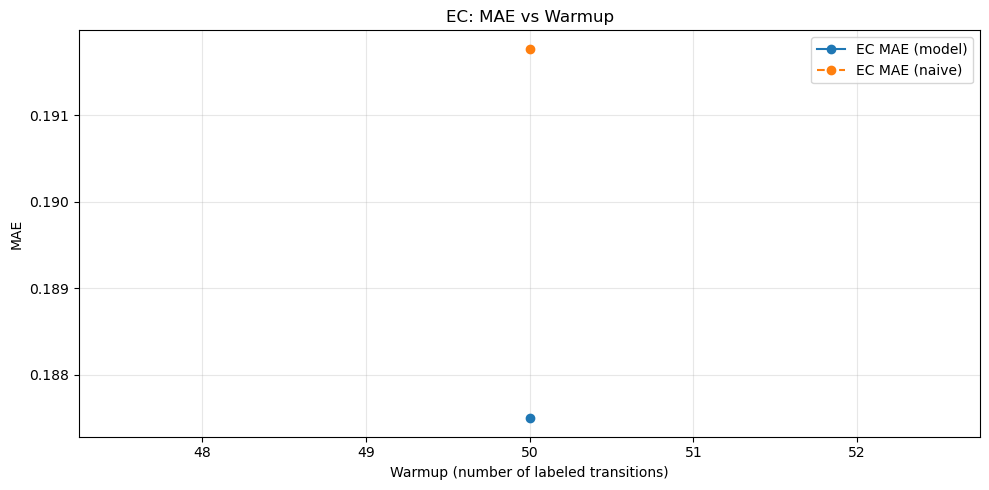

In [111]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(summary['warmup'], summary['ph_mae'], marker='o', label='pH MAE (model)')
ax.plot(summary['warmup'], summary['ph_mae_naive'], marker='o', linestyle='--', label='pH MAE (naive)')

ax.set_xlabel('Warmup (number of labeled transitions)')
ax.set_ylabel('MAE')
ax.set_title('pH: MAE vs Warmup')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(summary['warmup'], summary['ec_mae'], marker='o', label='EC MAE (model)')
ax.plot(summary['warmup'], summary['ec_mae_naive'], marker='o', linestyle='--', label='EC MAE (naive)')

ax.set_xlabel('Warmup (number of labeled transitions)')
ax.set_ylabel('MAE')
ax.set_title('EC: MAE vs Warmup')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

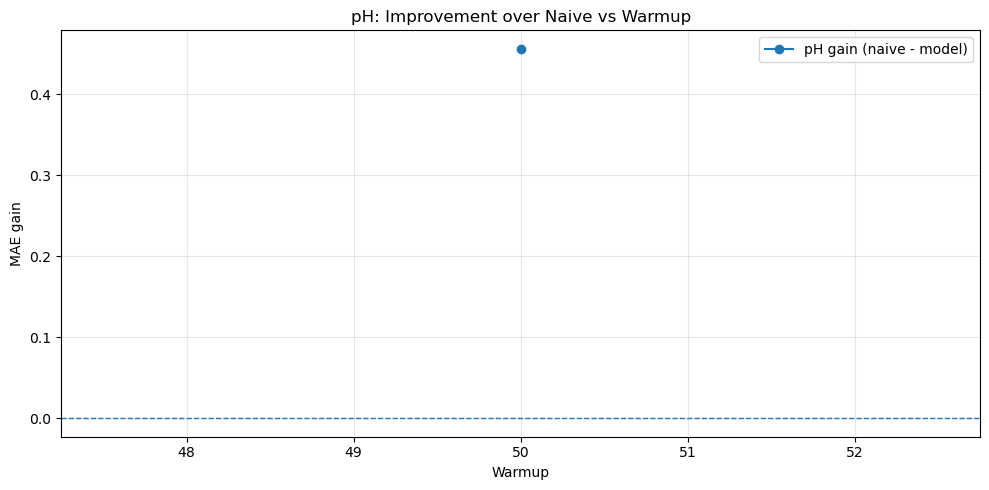

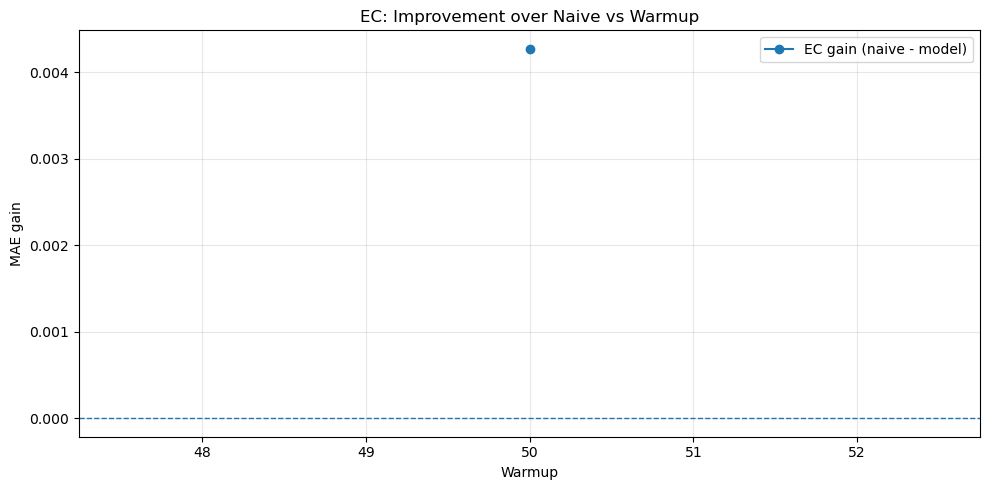

In [112]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(summary['warmup'], summary['ph_gain_mae'], marker='o', label='pH gain (naive - model)')
ax.axhline(0, linestyle='--', linewidth=1)

ax.set_xlabel('Warmup')
ax.set_ylabel('MAE gain')
ax.set_title('pH: Improvement over Naive vs Warmup')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(summary['warmup'], summary['ec_gain_mae'], marker='o', label='EC gain (naive - model)')
ax.axhline(0, linestyle='--', linewidth=1)

ax.set_xlabel('Warmup')
ax.set_ylabel('MAE gain')
ax.set_title('EC: Improvement over Naive vs Warmup')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()